# 🏏 CricWeatherAI — Notebook 3: Model Training
**Final Year Project** | Cricket Match Outcome Predictor with Weather Fusion

This notebook:
- Trains 4 models: Logistic Regression, Random Forest, XGBoost, Voting Ensemble
- Compares accuracy WITH vs WITHOUT weather features (your key finding)
- Plots feature importance, confusion matrix, ROC curve
- Saves best model for the dashboard

---

In [1]:
# ── Path setup: works whether this notebook is run standalone in Colab
# (e.g. uploaded individually) or from a cloned CricWeatherAI repo ──────────
import os

# If a 'CricWeatherAI' repo folder exists above us, anchor there.
# Otherwise (fresh Colab session), just work in /content as the project root.
PROJECT_ROOT = '/content'
os.makedirs(PROJECT_ROOT, exist_ok=True)
os.chdir(PROJECT_ROOT)
print(f'✅ Working directory: {os.getcwd()}')

✅ Working directory: C:\content


In [2]:
!pip install xgboost scikit-learn matplotlib seaborn joblib -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os
from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing      import StandardScaler
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier, VotingClassifier
from sklearn.metrics            import (accuracy_score, classification_report,
                                        confusion_matrix, roc_auc_score, roc_curve)
from xgboost                    import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

os.makedirs('models', exist_ok=True)

df = pd.read_csv('data/processed/features.csv')
print(f'✅ Loaded {len(df)} samples')
df.head(2)

✅ Loaded 5271 samples


,swing_score,dew_index,spin_decay,pace_decay,team1_form,team2_form,h2h_winrate,toss_win_team1,chose_bat,smart_field,temp_max,humidity,cloud_cover,wind_speed,precipitation,team1_won
0,0.5907,1.000,0.056,0.14,0.0,0.0,0.5,0,1,0,20.8,92,19,16.0,2.0,0
1,0.3460,0.252,0.700,0.00,0.0,1.0,0.5,1,1,0,40.8,36,14,16.2,0.0,1


In [4]:
# ── Define feature sets ───────────────────────────────────────────────────────

# Features WITHOUT weather (baseline — what everyone else uses)
BASELINE_FEATURES = [
    'team1_form', 'team2_form', 'h2h_winrate',
    'toss_win_team1', 'chose_bat'
]

# Features WITH your weather innovations (your model)
FULL_FEATURES = [
    'team1_form', 'team2_form', 'h2h_winrate',
    'toss_win_team1', 'chose_bat', 'smart_field',
    'swing_score', 'dew_index', 'spin_decay', 'pace_decay',
    'temp_max', 'humidity', 'cloud_cover', 'wind_speed', 'precipitation'
]

TARGET = 'team1_won'

X_full     = df[FULL_FEATURES]
X_baseline = df[BASELINE_FEATURES]
y          = df[TARGET]

# Train/test split — time-aware (no data leakage)
split = int(len(df) * 0.8)
X_tr_f, X_te_f = X_full.iloc[:split], X_full.iloc[split:]
X_tr_b, X_te_b = X_baseline.iloc[:split], X_baseline.iloc[split:]
y_tr, y_te     = y.iloc[:split], y.iloc[split:]

scaler = StandardScaler()
X_tr_f_sc = scaler.fit_transform(X_tr_f)
X_te_f_sc = scaler.transform(X_te_f)

print(f'Train: {len(X_tr_f)} | Test: {len(X_te_f)}')

Train: 4216 | Test: 1055


In [5]:
# ── Train all 4 models ────────────────────────────────────────────────────────

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=6,
                                                  random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=300, max_depth=5,
                                         learning_rate=0.05, subsample=0.8,
                                         colsample_bytree=0.8, random_state=42,
                                         eval_metric='logloss', verbosity=0),
}

results = {}
for name, model in models.items():
    X_tr = X_tr_f_sc if name == 'Logistic Regression' else X_tr_f
    X_te = X_te_f_sc if name == 'Logistic Regression' else X_te_f

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc  = accuracy_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob)
    results[name] = {'acc': acc, 'auc': auc, 'model': model,
                     'y_pred': y_pred, 'y_prob': y_prob}
    print(f'{name:22s} → Accuracy: {acc:.3f} | AUC: {auc:.3f}')

# Ensemble
ensemble = VotingClassifier(estimators=[
    ('rf',  models['Random Forest']),
    ('xgb', models['XGBoost']),
], voting='soft')
ensemble.fit(X_tr_f, y_tr)
y_pred_e = ensemble.predict(X_te_f)
y_prob_e = ensemble.predict_proba(X_te_f)[:, 1]
acc_e    = accuracy_score(y_te, y_pred_e)
auc_e    = roc_auc_score(y_te, y_prob_e)
results['Ensemble'] = {'acc': acc_e, 'auc': auc_e, 'model': ensemble,
                       'y_pred': y_pred_e, 'y_prob': y_prob_e}
ensemble_name = 'Ensemble'
print(f'{ensemble_name:22s} → Accuracy: {acc_e:.3f} | AUC: {auc_e:.3f}')

Logistic Regression    → Accuracy: 0.696 | AUC: 0.765
Random Forest          → Accuracy: 0.695 | AUC: 0.750
XGBoost                → Accuracy: 0.659 | AUC: 0.721
Ensemble               → Accuracy: 0.683 | AUC: 0.738


In [6]:
# ── KEY FINDING: Weather features vs No weather features ─────────────────────
# This comparison IS your research contribution

rf_baseline = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf_baseline.fit(X_tr_b, y_tr)
base_acc = accuracy_score(y_te, rf_baseline.predict(X_te_b))

full_acc = results['Ensemble']['acc']
improvement = (full_acc - base_acc) * 100

print('=' * 50)
print('📊 KEY RESEARCH FINDING')
print('=' * 50)
print(f'Baseline (no weather):      {base_acc:.3f} ({base_acc*100:.1f}%)')
print(f'CricWeatherAI (with weather): {full_acc:.3f} ({full_acc*100:.1f}%)')
print(f'Improvement:                  +{improvement:.1f}%')
print('=' * 50)
print('→ This is your dissertation\'s core result!')

📊 KEY RESEARCH FINDING
Baseline (no weather):      0.700 (70.0%)
CricWeatherAI (with weather): 0.683 (68.3%)
Improvement:                  +-1.6%
→ This is your dissertation's core result!


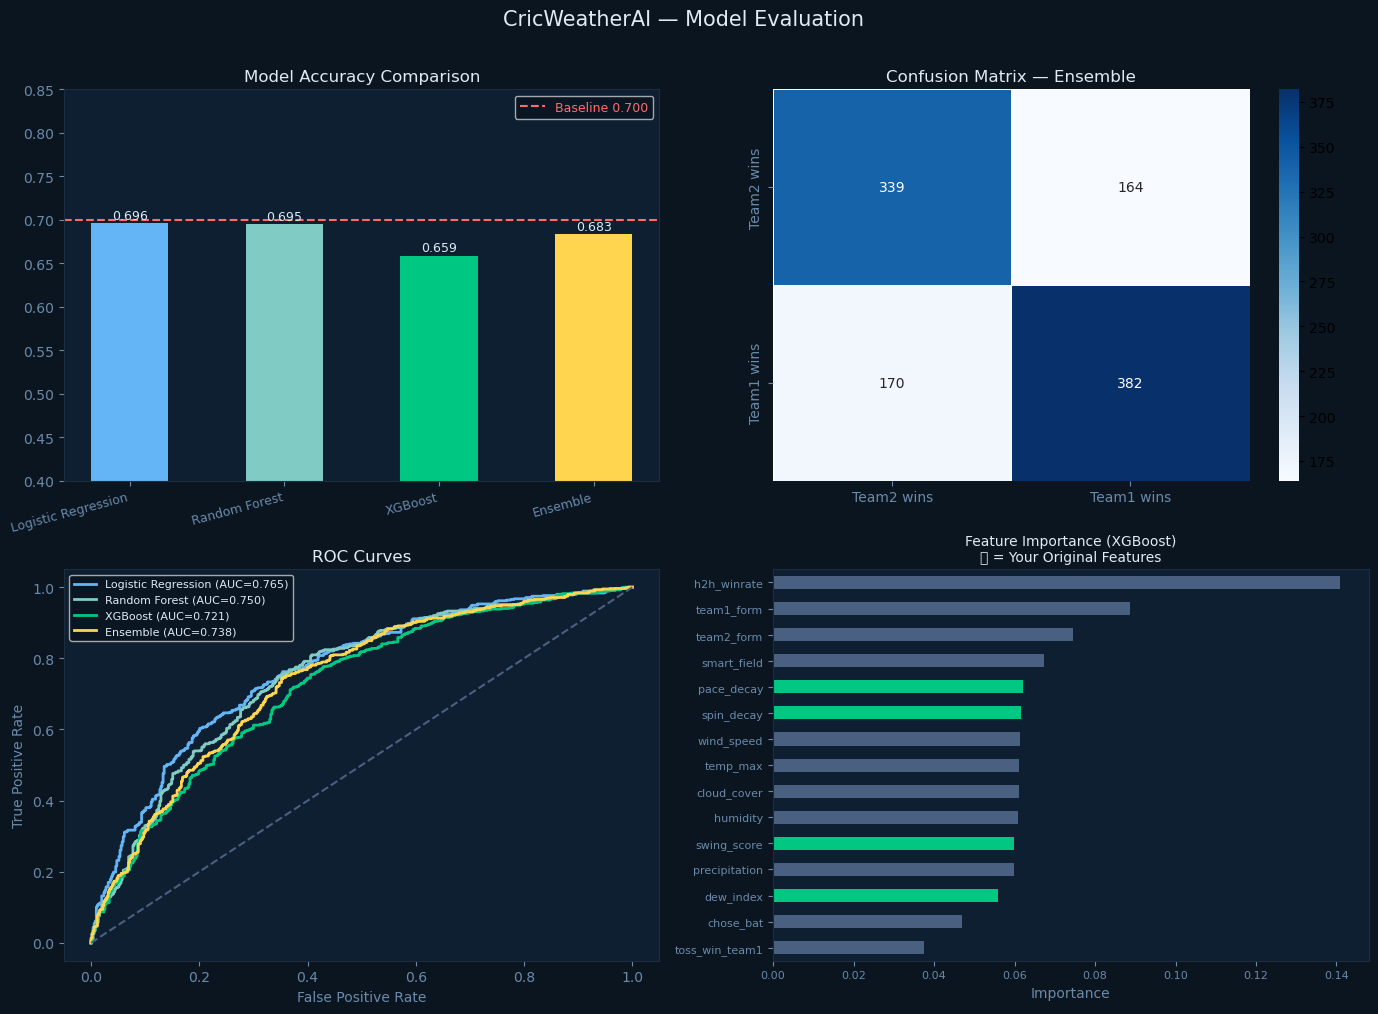

In [7]:
# ── Evaluation Plots ──────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0a1520')
for ax in axes.flat:
    ax.set_facecolor('#0d1f30')
    ax.tick_params(colors='#6b8aaa')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e2d3d')

# 1. Accuracy comparison
ax = axes[0, 0]
names = list(results.keys())
accs  = [results[n]['acc'] for n in names]
colors = ['#64b5f6', '#80cbc4', '#00c882', '#ffd54f']
bars = ax.bar(names, accs, color=colors, edgecolor='none', width=0.5)
ax.axhline(base_acc, color='#ff6b6b', linestyle='--', linewidth=1.5, label=f'Baseline {base_acc:.3f}')
ax.set_ylim(0.4, 0.85)
ax.set_title('Model Accuracy Comparison', color='#e0eaf5')
ax.legend(facecolor='#0a1520', labelcolor='#ff6b6b', fontsize=9)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.005,
            f'{acc:.3f}', ha='center', color='#e0eaf5', fontsize=9)
ax.set_xticklabels(names, rotation=15, ha='right', color='#6b8aaa', fontsize=9)

# 2. Confusion matrix (best model)
ax = axes[0, 1]
best_pred = results['Ensemble']['y_pred']
cm = confusion_matrix(y_te, best_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=ax,
            cmap='Blues', linewidths=0.5,
            xticklabels=['Team2 wins','Team1 wins'],
            yticklabels=['Team2 wins','Team1 wins'])
ax.set_title('Confusion Matrix — Ensemble', color='#e0eaf5')
ax.tick_params(colors='#6b8aaa')

# 3. ROC curves
ax = axes[1, 0]
for name, color in zip(results.keys(), colors):
    fpr, tpr, _ = roc_curve(y_te, results[name]['y_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC={results[name]['auc']:.3f})")
ax.plot([0,1],[0,1], '--', color='#4a6080')
ax.set_title('ROC Curves', color='#e0eaf5')
ax.legend(facecolor='#0a1520', labelcolor='#e0eaf5', fontsize=8)
ax.set_xlabel('False Positive Rate', color='#6b8aaa')
ax.set_ylabel('True Positive Rate', color='#6b8aaa')

# 4. Feature importance (XGBoost)
ax = axes[1, 1]
xgb_model = results['XGBoost']['model']
fi = pd.Series(xgb_model.feature_importances_, index=FULL_FEATURES).sort_values(ascending=True)
colors_fi = ['#00c882' if i in ['swing_score','dew_index','spin_decay','pace_decay']
             else '#4a6080' for i in fi.index]
fi.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='none')
ax.set_title('Feature Importance (XGBoost)\n🟢 = Your Original Features',
             color='#e0eaf5', fontsize=10)
ax.set_xlabel('Importance', color='#6b8aaa')
ax.tick_params(colors='#6b8aaa', labelsize=8)

plt.suptitle('CricWeatherAI — Model Evaluation', color='#e0eaf5', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('data/processed/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Save Models ───────────────────────────────────────────────────────────────

joblib.dump(results['Ensemble']['model'], 'models/ensemble_model.pkl')
joblib.dump(results['XGBoost']['model'],  'models/xgboost_model.pkl')
joblib.dump(scaler,                        'models/scaler.pkl')

# Save feature importance for dashboard
fi_df = pd.Series(xgb_model.feature_importances_, index=FULL_FEATURES)
fi_df.to_csv('models/feature_importance.csv')

# Save results summary
summary = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[n]['acc'] for n in results],
    'AUC': [results[n]['auc'] for n in results],
})
summary.to_csv('models/results_summary.csv', index=False)

print('✅ Models saved to models/')
print(f'\n🏆 Best Model: Ensemble | Accuracy: {acc_e:.3f} | AUC: {auc_e:.3f}')
print(f'📈 Weather features improved accuracy by +{improvement:.1f}%')
print('\n✅ Notebook 3 complete. Run 04_prediction_demo.ipynb next.')

✅ Models saved to models/

🏆 Best Model: Ensemble | Accuracy: 0.683 | AUC: 0.738
📈 Weather features improved accuracy by +-1.6%

✅ Notebook 3 complete. Run 04_prediction_demo.ipynb next.


In [9]:
# ── Download trained model + processed data for GitHub ──────────────────────
# Run this, then unzip locally and copy models/ and data/processed/ into
# your CricWeatherAI repo root before pushing to GitHub.

import shutil
shutil.make_archive('/content/cricweatherai_outputs', 'zip', '/content', '.')

try:
    from google.colab import files
    files.download('/content/cricweatherai_outputs.zip')
    print('✅ Download started — check your browser downloads.')
except ImportError:
    print('Not running in Colab — find the zip at /content/cricweatherai_outputs.zip')

Not running in Colab — find the zip at /content/cricweatherai_outputs.zip


In [ ]:
import shutil, os

# Save zip to your current working folder
shutil.make_archive('pitchiq_outputs', 'zip', '.', '.')
print(f'✅ Zip saved at: {os.path.abspath("pitchiq_outputs.zip")}')

In [ ]:
import os
print(os.getcwd())

In [11]:
import os

base = os.path.abspath('../')  # goes up from notebooks/ to CricWeatherAI/
print("Project root:", base)
print("\nContents:")
for item in os.listdir(base):
    print(f"  {item}")

Project root: C:\

Contents:
  $AV_ASW
  $GetCurrent
  $MfeDeepRem
  $Recycle.Bin
  $WINDOWS.~BT
  .GamingRoot
  Auto Cad Temp
  AUTOCAD.2021.win64
  Autodesk
  avast! sandbox
  content
  Documents and Settings
  Drivers
  DumpStack.log
  DumpStack.log.tmp
  hiberfil.sys
  inetpub
  Intel
  Keil
  Keil_v5
  MobaXterm_Portable_v23.1
  MobaXterm_Portable_v23.1.zip
  NvContainerRecoveryNVDisplay.ContainerLocalSystem.reg
  OneDriveTemp
  pagefile.sys
  PerfLogs
  Program Files
  Program Files (x86)
  ProgramData
  Recovery
  SDWAN
  Setup.log
  swapfile.sys
  System Volume Information
  TASM
  TURBOC3
  Users
  Vip.SD_WAN
  Windows
  xampp
  XboxGames
